In [1]:
import pandas as pd
import numpy as np
from joblib import load
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 特徵工程

In [2]:
df = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\function_dataset_cleaned.csv')
X = df.drop(columns=['label'])
y = df['label']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

In [4]:
# 先將原本100個欄位拿去訓練模型
model = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\best_model.joblib')
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"準確度: {accuracy:.3f}")

準確度: 0.821


In [6]:
print(f"混淆矩陣:\n{confusion_matrix(y_test, y_pred)}")

混淆矩陣:
[[95  0  0  0  2  2  0  1]
 [ 0 85  0  2  2 10  0  1]
 [ 0  1 87  0  0  2 10  0]
 [ 0  1  9 73  4  0 12  1]
 [ 5  0  8  6 70  2  9  0]
 [ 2  5  2  8  7 73  1  2]
 [ 0  0  6  5  4  2 83  0]
 [ 4  0  1  0  1  1  2 91]]


In [7]:
print(f"分類報告:\n{classification_report(y_test, y_pred)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.90      0.95      0.92       100
       cubic       0.92      0.85      0.89       100
 exponential       0.77      0.87      0.82       100
      linear       0.78      0.73      0.75       100
 logarithmic       0.78      0.70      0.74       100
   quadratic       0.79      0.73      0.76       100
  reciprocal       0.71      0.83      0.76       100
        sine       0.95      0.91      0.93       100

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800



In [8]:
# 將原始資料標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 訓練集

In [9]:
train_first_diff = np.diff(X_train.values, axis=1)          # 一階差分
train_second_diff = np.diff(X_train.values, n=2, axis=1)    # 二階差分
train_amplitude = X_train.max(axis=1) - X_train.min(axis=1) # 變化總幅度

train_x = np.linspace(-2, 2, X_train.shape[1]).reshape(-1, 1)
train_slopes = []                                           # 每一筆函數的整體迴歸斜率
for row in X_train.values:
    train_model = LinearRegression()
    train_model.fit(train_x, row)
    train_slopes.append(train_model.coef_[0])
train_slopes = np.array(train_slopes) 

In [10]:
print(f"訓練數據的形狀: {X_train_scaled.shape}")

訓練數據的形狀: (3200, 100)


In [11]:
print(f"原始最大值:\n{X_train.max(axis=0)}\n")              # 最大值
print(f"標準化後的最大值:\n{X_train_scaled.max(axis=0)}\n")

原始最大值:
y_000    19.516391
y_001    17.969906
y_002    17.504949
y_003    16.425775
y_004    15.546557
           ...    
y_095    16.112309
y_096    16.635983
y_097    17.456970
y_098    18.585863
y_099    18.986480
Length: 100, dtype: float64

標準化後的最大值:
[4.62547743 4.42319885 4.4856857  4.36301145 4.2829817  4.30000758
 4.36878522 4.22254207 4.50477391 4.17495722 4.01208525 4.14887202
 4.04419967 4.07575445 3.96392289 3.75466789 3.78087886 3.65481
 3.80613254 3.35027633 3.62466769 3.76431905 3.47591875 3.42039211
 3.16273374 2.97571571 2.83152982 2.99015491 2.77308125 2.7692918
 3.00958413 2.60561532 2.57604612 2.54309203 2.51204422 2.50218557
 2.56765927 2.36985855 2.54439045 2.46677669 2.64660235 2.65017168
 2.59748237 2.55007875 2.52697078 2.67071984 2.67180003 2.80235228
 2.77190999 2.73679135 2.81418965 2.80094018 2.79833972 2.76820471
 2.76254233 2.72836859 2.69743554 2.91993088 2.53097803 2.77164826
 2.69543899 2.56179814 2.55963785 2.59983794 2.63843873 2.7756881
 2.74530895 2

In [12]:
print(f"原始最小值:\n{X_train.min(axis=0)}\n")              # 最小值
print(f"標準化後的最小值:\n{X_train_scaled.min(axis=0)}\n")

原始最小值:
y_000   -18.046258
y_001   -17.189638
y_002   -16.344650
y_003   -15.721408
y_004   -14.734648
           ...    
y_095   -16.800721
y_096   -17.198838
y_097   -18.420420
y_098   -19.196022
y_099   -20.150363
Length: 100, dtype: float64

標準化後的最小值:
[-4.43937482 -4.40093983 -4.36085689 -4.35506082 -4.24069542 -4.24044417
 -4.28832238 -4.12838855 -4.04890487 -4.05010011 -3.97259261 -3.91526167
 -3.98109376 -3.89862646 -3.82142699 -3.74063001 -3.70966883 -3.62955859
 -3.71470463 -3.5135106  -3.63479254 -3.34677477 -3.54652708 -3.17840869
 -3.11260592 -3.12960329 -3.1701063  -3.02304256 -2.84932832 -2.77723764
 -2.86652343 -2.83927402 -2.72156016 -2.74723504 -2.81254618 -2.72281139
 -2.62190353 -2.66870156 -2.67886161 -2.71143062 -2.6577626  -2.75313128
 -2.86080897 -2.96802623 -2.85654132 -2.94015689 -2.89123724 -2.8326969
 -2.60856228 -2.64153089 -2.62494531 -2.6785275  -2.66089764 -2.7075827
 -2.70645877 -2.68903808 -2.68162848 -2.68961849 -2.60870479 -2.97118942
 -2.73792072 -2.8

In [13]:
print(f"原始平均值:\n{X_train.mean(axis=0)}\n") 

原始平均值:
y_000    0.349484
y_001    0.345789
y_002    0.341333
y_003    0.337525
y_004    0.330841
           ...   
y_095    0.237021
y_096    0.251712
y_097    0.256921
y_098    0.264700
y_099    0.275633
Length: 100, dtype: float64



In [14]:
print(f"原始標準差:\n{X_train.std(axis=0)}\n")

原始標準差:
y_000    4.144416
y_001    3.985096
y_002    3.826906
y_003    3.687995
y_004    3.553154
           ...   
y_095    3.425225
y_096    3.557164
y_097    3.691980
y_098    3.840059
y_099    3.989270
Length: 100, dtype: float64



In [15]:
print(f"迴歸斜率:(取前5筆資料)\n{train_slopes[:5]}\n")

迴歸斜率:(取前5筆資料)
[ 0.78529431 -0.32550953  0.6782538  -1.53071435  0.42824123]



In [16]:
print("經過一階差分處理後的結果:(取前5筆資料)")
train_first_diff_mean = train_first_diff.mean(axis=1)
train_first_diff_std = train_first_diff.std(axis=1)
print(f"平均值:\n{train_first_diff_mean[:5]}")
print(f"標準差:\n{train_first_diff_std[:5]}\n")

經過一階差分處理後的結果:(取前5筆資料)
平均值:
[ 0.08496235 -0.00619512  0.0306902  -0.06203064  0.01635952]
標準差:
[0.22659983 0.21793702 0.04085547 0.20843336 0.1083672 ]



In [17]:
print("經過二階差分處理後的結果:(取前5筆資料)")
train_second_diff_mean = train_second_diff.mean(axis=1)
train_second_diff_std = train_second_diff.std(axis=1)
print(f"平均值:\n{train_second_diff_mean[:5]}")
print(f"標準差:\n{train_second_diff_std[:5]}\n")

經過二階差分處理後的結果:(取前5筆資料)
平均值:
[ 0.00604781 -0.00016565  0.00074533  0.00160426 -0.00206207]
標準差:
[0.28599016 0.21014113 0.05871959 0.33740008 0.16131296]



In [18]:
print(f"變化幅度:(取前5筆資料)\n{train_amplitude[:5]}\n")

變化幅度:(取前5筆資料)
1025    8.624828
3173    4.284245
1817    3.038330
959     7.195399
732     3.253515
dtype: float64



In [19]:
# 建立 X_train 的6個數學特徵(斜率, 總變化量, 一階差分, 二階差分)
train_math_features = pd.DataFrame({'slope': train_slopes,
                                    'amplitude': train_amplitude,
                                    'first_diff_mean': train_first_diff_mean,
                                    'first_diff_std': train_first_diff_std,
                                    'second_diff_mean': train_second_diff_mean,
                                    'second_diff_std': train_second_diff_std})
print(f"X_train數學特徵前5筆:\n{train_math_features.head()}")
print(f"形狀: {train_math_features.shape}")

X_train數學特徵前5筆:
         slope  amplitude  first_diff_mean  first_diff_std  second_diff_mean  \
1025  0.785294   8.624828         0.084962        0.226600          0.006048   
3173 -0.325510   4.284245        -0.006195        0.217937         -0.000166   
1817  0.678254   3.038330         0.030690        0.040855          0.000745   
959  -1.530714   7.195399        -0.062031        0.208433          0.001604   
732   0.428241   3.253515         0.016360        0.108367         -0.002062   

      second_diff_std  
1025         0.285990  
3173         0.210141  
1817         0.058720  
959          0.337400  
732          0.161313  
形狀: (3200, 6)


In [20]:
# 加入原始特徵
X_train_math = pd.concat([X_train.reset_index(drop=True), 
                          train_math_features.reset_index(drop=True)], axis=1)
print("加入原始特徵後:")
print(f"X_train_math 形狀為: {X_train_math.shape}")

加入原始特徵後:
X_train_math 形狀為: (3200, 106)


### 測試集

In [21]:
test_first_diff = np.diff(X_test.values, axis=1)            # 一階差分
test_second_diff = np.diff(X_test.values, n=2, axis=1)      # 二階差分
test_amplitude = X_test.max(axis=1) - X_test.min(axis=1)    # 變化總幅度

test_x = np.linspace(-2, 2, X_test.shape[1]).reshape(-1, 1)
test_slopes = []                                            # 每一筆函數的整體迴歸斜率
for row in X_test.values:
    test_model = LinearRegression()
    test_model.fit(test_x, row)
    test_slopes.append(test_model.coef_[0])
test_slopes = np.array(test_slopes)

# 一階差分統計
test_first_diff_mean = test_first_diff.mean(axis=1)
test_first_diff_std = test_first_diff.std(axis=1)
# 二階差分統計
test_second_diff_mean = test_second_diff.mean(axis=1)
test_second_diff_std = test_second_diff.std(axis=1)

# 建立 X_test 的6個數學特徵(斜率, 總變化量, 一階差分, 二階差分)
test_math_features = pd.DataFrame({'slope': test_slopes,
                                   'amplitude': test_amplitude,
                                   'first_diff_mean': test_first_diff_mean,
                                   'first_diff_std': test_first_diff_std,
                                   'second_diff_mean': test_second_diff_mean,
                                   'second_diff_std': test_second_diff_std})
print(f"X_test數學特徵前5筆:\n{test_math_features.head()}")
print(f"形狀: {test_math_features.shape}")

X_test數學特徵前5筆:
         slope  amplitude  first_diff_mean  first_diff_std  second_diff_mean  \
669   1.948086   7.847387         0.079267        0.140128          0.000807   
622   1.618746   8.776037         0.064200        0.184493         -0.004878   
2417 -0.031335   2.160810        -0.001713        0.068507         -0.000416   
3925 -0.298788   1.698776        -0.017159        0.032860          0.001330   
2662 -0.146187   3.229009        -0.024954        0.133175          0.000709   

      second_diff_std  
669          0.230816  
622          0.247981  
2417         0.094211  
3925         0.042399  
2662         0.154023  
形狀: (800, 6)


In [22]:
# 加入原始特徵
X_test_math = pd.concat([X_test.reset_index(drop=True),
                         test_math_features.reset_index(drop=True)], axis=1)
print("加入原始特徵後:")
print(f"X_test_math 形狀為: {X_test_math.shape}")

加入原始特徵後:
X_test_math 形狀為: (800, 106)


### 把訓練集跟測試集結合成一個大表格

In [23]:
X_math_merged = pd.concat([X_train_math.reset_index(drop=True), 
                           X_test_math.reset_index(drop=True)], axis=0)
print("把訓練數據跟測試數據合併之後")
print(f"形狀為: {X_math_merged.shape}")

把訓練數據跟測試數據合併之後
形狀為: (4000, 106)


### 將合併後的表格儲存成新的檔案

In [24]:
y_merged = pd.concat([y_train.reset_index(drop=True), 
                      y_test.reset_index(drop=True)], axis=0)
math_merged = pd.concat([y_merged, X_math_merged], axis=1)
math_merged.to_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\function_dataset_merged.csv', index=False)

In [25]:
# 儲存成網頁
math_merged.to_html(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\Math_Function_Dataset_Feature_Engineering.html')

### 標準化

In [26]:
scaler_after = StandardScaler()
X_train_math_scaled = scaler_after.fit_transform(X_train_math)
X_test_math_scaled = scaler_after.transform(X_test_math)

In [27]:
print(f"標準化之後的平均值:\n{X_train_math_scaled.mean(axis=0)}")

標準化之後的平均值:
[ 1.33226763e-17  2.22044605e-18  0.00000000e+00  5.55111512e-18
 -1.77635684e-17 -2.22044605e-18  7.77156117e-18  4.44089210e-18
  2.22044605e-18 -6.66133815e-18 -1.77635684e-17 -6.66133815e-18
  0.00000000e+00  8.88178420e-18 -2.22044605e-17  8.88178420e-18
  8.88178420e-18  2.22044605e-18 -8.88178420e-18  2.22044605e-18
  4.44089210e-18  8.88178420e-18  8.88178420e-18 -4.44089210e-18
  2.22044605e-18 -2.66453526e-17  6.66133815e-18 -2.88657986e-17
 -3.77475828e-17 -6.66133815e-18 -1.77635684e-17  6.66133815e-18
  1.11022302e-17  1.99840144e-17  4.44089210e-18  2.44249065e-17
 -2.44249065e-17 -1.33226763e-17  6.66133815e-18 -1.99840144e-17
  0.00000000e+00  1.22124533e-17 -1.33226763e-17  2.22044605e-18
  1.33226763e-17  3.33066907e-18 -4.44089210e-18  1.11022302e-18
 -2.44249065e-17 -3.33066907e-17  1.11022302e-17 -2.10942375e-17
 -8.88178420e-18 -2.27595720e-17  2.44249065e-17  6.66133815e-18
  3.88578059e-18  3.88578059e-17  1.66533454e-18 -3.19189120e-17
 -2.33146835e-

In [28]:
print(f"標準化之後的標準差:\n{X_train_math_scaled.std(axis=0)}")

標準化之後的標準差:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 將結合後的數據再訓練模型一次

In [29]:
model_math = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\best_model.joblib')
model_math.fit(X_train_math, y_train.reset_index(drop=True))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
y_pred_math = model_math.predict(X_test_math)
math_accuracy = accuracy_score(y_test.reset_index(drop=True), y_pred_math)
print(f"準確度: {math_accuracy:.3f}")

準確度: 0.816


In [31]:
print(f"混淆矩陣:\n{confusion_matrix(y_test.reset_index(drop=True), y_pred_math)}")

混淆矩陣:
[[95  0  0  0  1  2  1  1]
 [ 0 85  0  2  1 11  0  1]
 [ 0  1 86  1  0  2 10  0]
 [ 0  1  9 72  4  1 12  1]
 [ 4  0  9  5 69  1 11  1]
 [ 1  4  2  8  9 73  2  1]
 [ 0  1  9  3  5  2 80  0]
 [ 4  0  1  0  1  0  1 93]]


In [32]:
print(f"分類報告:\n{classification_report(y_test.reset_index(drop=True), y_pred_math)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.91      0.95      0.93       100
       cubic       0.92      0.85      0.89       100
 exponential       0.74      0.86      0.80       100
      linear       0.79      0.72      0.75       100
 logarithmic       0.77      0.69      0.73       100
   quadratic       0.79      0.73      0.76       100
  reciprocal       0.68      0.80      0.74       100
        sine       0.95      0.93      0.94       100

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800



### 比較結果

In [33]:
improvement = math_accuracy - accuracy
# 以下是本次實驗的總整理
print(f"原始特徵準確度: {accuracy:.3f}")
print(f"數學特徵準確度: {math_accuracy:.3f}")
print(f"比原本特徵進步了: {improvement:+.3f}")
print("結論:", end=" ")
if improvement > 0:
    print("加入數學特徵後, 準確度提升。")
elif improvement < 0:
    print("加入數學特徵後, 準確度下降。")
else:
    print("加入數學特徵後, 準確度沒有改變。")

原始特徵準確度: 0.821
數學特徵準確度: 0.816
比原本特徵進步了: -0.005
結論: 加入數學特徵後, 準確度下降。


## 特徵重要性

In [34]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [35]:
feature_importance = model_math.feature_importances_
feature_names = X_train_math.columns
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importance})

In [36]:
# 由高到低排序
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Feature Importance 前20名
print(importance_df.head(20).to_string(index=False, formatters={'Importance': '{:.4f}'.format}))

         Feature Importance
       amplitude     0.0506
 first_diff_mean     0.0305
  first_diff_std     0.0296
           slope     0.0191
           y_099     0.0190
           y_000     0.0182
 second_diff_std     0.0176
           y_098     0.0174
           y_001     0.0160
           y_002     0.0157
           y_097     0.0154
           y_096     0.0153
           y_095     0.0139
second_diff_mean     0.0138
           y_094     0.0130
           y_046     0.0119
           y_003     0.0116
           y_050     0.0114
           y_093     0.0112
           y_065     0.0111


In [37]:
importance_df.to_html(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\feature_importance.html')
print("\n已儲存至網頁!\n")


已儲存至網頁!



In [38]:
math_feature_names = ['slope', 'amplitude', 'first_diff_mean', 'first_diff_std', 
                      'second_diff_mean', 'second_diff_std']
math_importance_df = importance_df[importance_df['Feature'].isin(math_feature_names)].copy()
print(math_importance_df.to_string(index=False, formatters={'Importance': '{:.4f}'.format}))

         Feature Importance
       amplitude     0.0506
 first_diff_mean     0.0305
  first_diff_std     0.0296
           slope     0.0191
 second_diff_std     0.0176
second_diff_mean     0.0138


In [39]:
math_total_importance = (math_importance_df['Importance'].sum())    # 計算數學特徵的重要性總和
raw_total_importance = (importance_df[~importance_df['Feature'].isin(math_feature_names)]['Importance'].sum())

# 特徵群組重要性
print(f"原始 100 個 y 特徵重要性總和: {raw_total_importance:.4f}")
print(f"6 個數學特徵重要性總和: {math_total_importance:.4f}\n")

原始 100 個 y 特徵重要性總和: 0.8388
6 個數學特徵重要性總和: 0.1612



In [40]:
most_important_math = (math_importance_df.iloc[0])      # 找出最重要的數學特徵
print(f"最重要的數學特徵: {most_important_math['Feature']} ({most_important_math['Importance']:.6f})")

最重要的數學特徵: amplitude (0.050568)


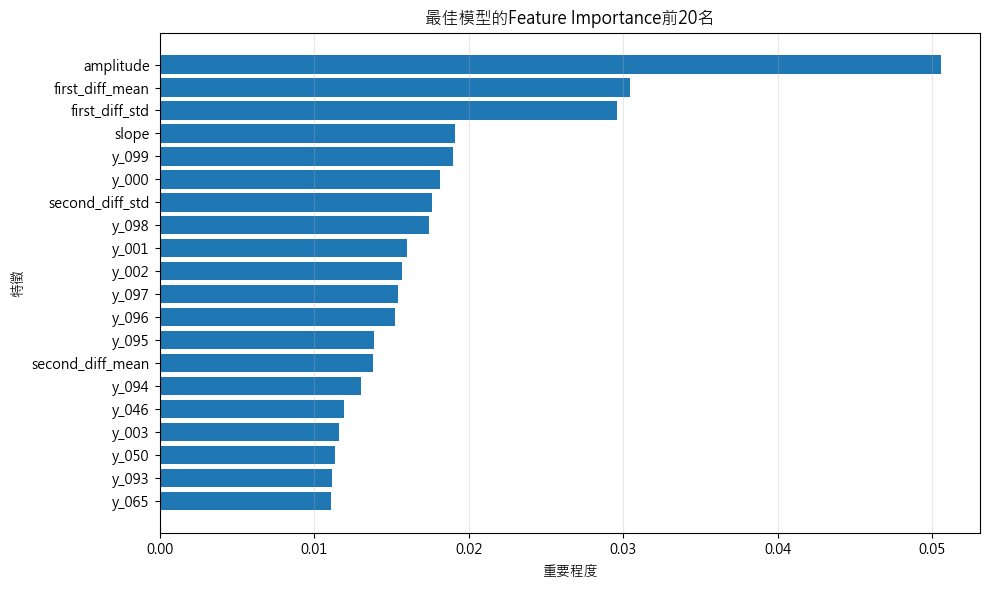

In [41]:
# 畫出前 20 名 Feature Importance
top_n = 20
top_features = importance_df.head(top_n).copy()
top_features = top_features.sort_values(by='Importance', ascending=True)    # 為了畫圖讓最重要的在最上面

# 繪製圖表
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("重要程度")
plt.ylabel("特徵")
plt.title("最佳模型的Feature Importance前20名")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()